In [1]:
# %pip install -r requirements.txt

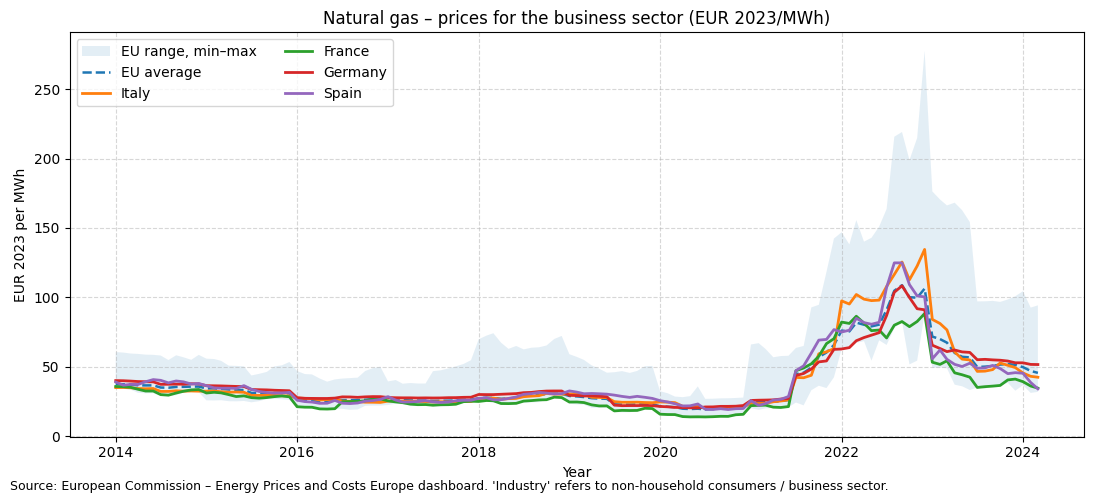

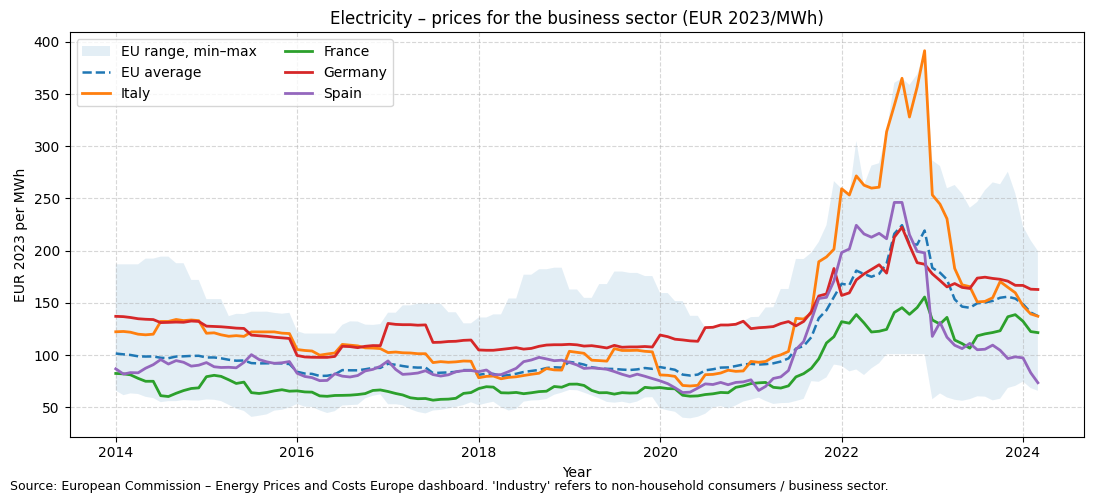

In [2]:
"""
Time series of energy prices for the business sector, non-household consumers:
Italy, France, Germany and Spain.

Source: European Commission – Energy Prices and Costs Europe dashboard.
CSV files can be downloaded from the official link reported in the repository README.
"""

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

# --- Robust reading ---

def read_csv_robust(path: str) -> pd.DataFrame:
    # Auto-detect separator, handle BOM and clean headers
    df = pd.read_csv(path, sep=None, engine="python", encoding="utf-8-sig")
    df.columns = [c.strip() for c in df.columns]
    return df

def _norm(s: str) -> str:
    s = s.lower()
    s = re.sub(r"[\s_/()-]+", "", s)
    return s

def find_col(df: pd.DataFrame, name: str) -> str:
    wanted = _norm(name)
    for c in df.columns:
        if _norm(c) == wanted:
            return c
    for c in df.columns:
        if wanted in _norm(c):
            return c
    raise KeyError(f"Column '{name}' not found. Available columns: {list(df.columns)}")

# --- Multi-country plot ---

def plot_multi_countries(
    file_path: str,
    countries=("Italy", "France", "Germany", "Spain"),
    show_eu_band=True,
    title="",
    ylab="EUR 2023 per MWh",
    save_png=False
):
    df = read_csv_robust(file_path)

    col_date = find_col(df, "Category")  # e.g. '2014-1'
    col_euavg = find_col(df, "EU Average")
    col_eumin = find_col(df, "EU Min")
    col_eumax = find_col(df, "EU Max")
    country_cols = {c: find_col(df, c) for c in countries}

    # Date parsing, YYYY-M
    cat = df[col_date].astype(str).str.strip()
    cat = cat.str.replace(r"^(\d{4})-(\d{1})$", r"\1-0\2", regex=True)
    df["Date"] = pd.to_datetime(cat, format="%Y-%m", errors="coerce")
    df = df.sort_values("Date").dropna(subset=["Date"])

    # Numeric conversions
    cols_to_num = [col_euavg, col_eumin, col_eumax] + list(country_cols.values())
    for c in cols_to_num:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Chart
    fig, ax = plt.subplots(figsize=(11, 5))

    if show_eu_band:
        ax.fill_between(
            df["Date"],
            df[col_eumin],
            df[col_eumax],
            alpha=0.12,
            label="EU range, min–max"
        )
        ax.plot(
            df["Date"],
            df[col_euavg],
            linestyle="--",
            linewidth=1.8,
            label="EU average"
        )

    for name, col in country_cols.items():
        ax.plot(df["Date"], df[col], linewidth=2, label=name)

    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylab)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(ncol=2)

    fig.text(
        0.01,
        0.01,
        (
            "Source: European Commission – Energy Prices and Costs Europe dashboard. "
            "'Industry' refers to non-household consumers / business sector."
        ),
        ha="left",
        fontsize=9
    )

    plt.tight_layout()

    if save_png:
        out = Path(file_path).with_suffix("")
        out = Path(str(out) + "_IT_FR_DE_ES_timeseries.png")
        plt.savefig(out, dpi=200)
        print(f"Saved: {out}")

    plt.show()

# ======= EXECUTION =======

# Natural gas
plot_multi_countries(
    file_path="Natural-Gas-Industry-retail-prices,-excluding-recoverable-taxes-and-levies-(EUR2023-MWh).csv",
    countries=("Italy", "France", "Germany", "Spain"),
    title="Natural gas – prices for the business sector (EUR 2023/MWh)"
)

# Electricity
plot_multi_countries(
    file_path="Electricity-Industry-retail-prices,-excluding-recoverable-taxes-and-levies-(EUR2023-MWh).csv",
    countries=("Italy", "France", "Germany", "Spain"),
    title="Electricity – prices for the business sector (EUR 2023/MWh)"
)